In [1]:
!git clone https://github.com/HoangHumg1210/hoankiem-air-quality-.git
%cd hoankiem-air-quality-
!git pull

Cloning into 'hoankiem-air-quality-'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 68 (delta 23), reused 60 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 7.77 MiB | 10.06 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/hoankiem-air-quality-
Already up to date.


In [2]:
# import os, sys

# PROJECT_ROOT = "/content/hoankiem-air-quality"  # thư mục chứa folder src/
# assert os.path.isdir(PROJECT_ROOT), f"Không thấy thư mục: {PROJECT_ROOT}"

# if PROJECT_ROOT not in sys.path:
#     sys.path.insert(0, PROJECT_ROOT)  # ưu tiên path này

In [3]:
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline




In [ ]:
from src.data_utils import (
    set_seed,
    load_and_clean_data,
    add_time_features,
    add_target_features,
    split_data,
    transform_target,
    preprocess_features,
    create_sequences
)

In [ ]:
TARGET = 'PM25'
LOOKBACK = 336
HORIZON = 8
USE_LOG_TARGET = True
DATA_PATH = 'data/processed/data2225_done.csv'


/tmp/ipykernel_5301/97321587.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)


Loaded df: (34769, 16)
After feature engineering: (34697, 35)
Train: (17153, 35)
Val  : (8784, 35)
Test : (8760, 35)
X_train: (17153, 43) y_train: (17153, 1)
X_val  : (8784, 43) y_val  : (8784, 1)
X_test : (8760, 43) y_test : (8760, 1)
Sequence shapes:
Train: (16746, 336, 43) (16746, 72)
Val  : (8377, 336, 43) (8377, 72)
Test : (8353, 336, 43) (8353, 72)
n_features = 43


In [25]:
def prepare_sequences_for_experiment(
    data_path: str,
    target: str = "PM25",
    transform: str = "log",  # "log" / "sqrt" / "none"
    lookback: int = 336,
    horizon: int = 72,
):
    """Chuẩn bị X_seq, y_seq cho 1 cấu hình thí nghiệm.

    Hàm này lặp lại đúng pipeline trong `src.data_utils` nhưng cho phép
    thay đổi transform target và tham số LOOKBACK / HORIZON.
    """
    df = load_and_clean_data(data_path)
    df = add_time_features(df)
    df = add_target_features(df, target=target)

    train_df, val_df, test_df = split_data(df)

    # 1) Transform target theo config
    y_train, y_val, y_test, scaler_y, inverse_target_transform = transform_target(
        train_df,
        val_df,
        test_df,
        target=target,
        transform=transform,
    )

    # 2) Preprocess features
    X_train, X_val, X_test, preprocess = preprocess_features(
        train_df,
        val_df,
        test_df,
        target=target,
    )

    # 3) Tạo sequence
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback=lookback, horizon=horizon)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback=lookback, horizon=horizon)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback=lookback, horizon=horizon)

    return {
        "df": df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "X_train_seq": X_train_seq,
        "y_train_seq": y_train_seq,
        "X_val_seq": X_val_seq,
        "y_val_seq": y_val_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "scaler_y": scaler_y,
        "inverse_target_transform": inverse_target_transform,
        "preprocess": preprocess,
        "lookback": lookback,
        "horizon": horizon,
        "transform": transform,
    }



def build_cnn_gru_model(
    n_features: int,
    lookback: int,
    horizon: int,
    arch: str = "heavy"
):
    """Xây dựng kiến trúc CNN-GRU cho multi-step forecasting."""
    if arch == "heavy":
        model = Sequential([
            Conv1D(
                filters=64,
                kernel_size=3,
                activation="relu",
                padding="same",
                input_shape=(lookback, n_features)
            ),
            Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),

            GRU(256, return_sequences=True),
            Dropout(0.2),
            GRU(128, return_sequences=True),
            Dropout(0.2),
            GRU(64, return_sequences=False),
            Dropout(0.2),

            Dense(32, activation="relu"),
            Dense(horizon),
        ])

    elif arch == "light":
        model = Sequential([
            GRU(128, return_sequences=True, input_shape=(lookback, n_features)),
            Dropout(0.1),
            GRU(64, return_sequences=False),
            Dropout(0.1),
            Dense(32, activation="relu"),
            Dense(horizon),
        ])
    else:
        raise ValueError(f"Unknown arch type: {arch}")

    return model


Running experiment: A_no_log_MSE_h8_l336_cnn_gru_heavy
Config: {'name': 'A_no_log_MSE_h8_l336_cnn_gru_heavy', 'transform': 'none', 'lookback': 168, 'horizon': 3, 'loss': 'mse', 'arch': 'heavy'}


/content/hoankiem-air-quality-/src/data_utils.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.9703 - mae: 0.4494 - val_loss: 0.9444 - val_mae: 0.6885 - learning_rate: 0.0010
Epoch 2/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.7335 - mae: 0.3835 - val_loss: 0.8081 - val_mae: 0.6606 - learning_rate: 0.0010
Epoch 3/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.6297 - mae: 0.3545 - val_loss: 1.0182 - val_mae: 0.7261 - learning_rate: 0.0010
Epoch 4/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.5530 - mae: 0.3393 - val_loss: 1.1647 - val_mae: 0.7456 - learning_rate: 0.0010
Epoch 5/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.5067 - mae: 0.3269 - val_loss: 0.8720 - val_mae: 0.6802 - learning_rate: 0.0010
Epoch 6/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.4958 - mae: 0.3185 - val_loss: 0.9302 - val_mae: 0.6843 - learning_rate: 0.0010
Epoch 7/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.4519 - mae: 0.3084 - val_loss: 0.6700 - val_mae: 0.5798 - learning_rate

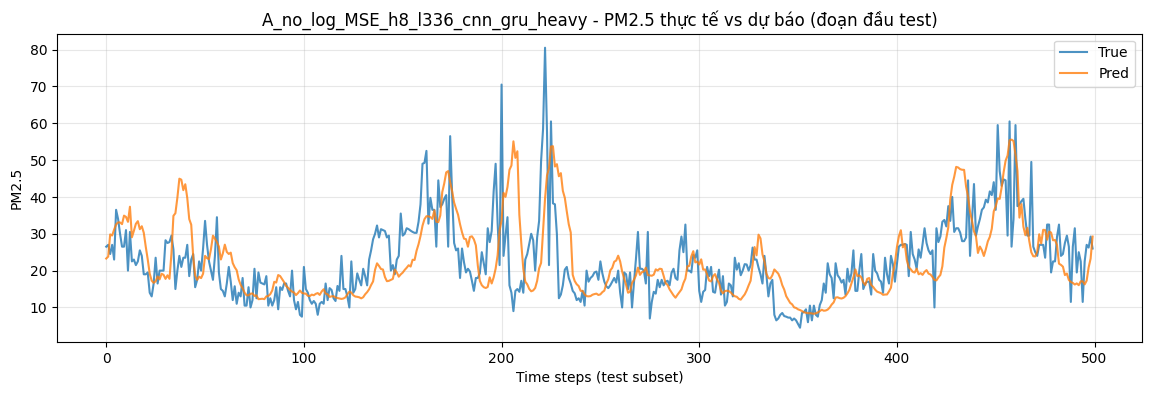


=== Tóm tắt kết quả các cấu hình ===
A_no_log_MSE_h8_l336_cnn_gru_heavy: transform=none, loss=mse, lookback=168, horizon=3 | MAE=9.7978, RMSE=14.7904


In [ ]:

experiment_configs = [
    {
        "name": "A_no_log_MSE_h8_l336_cnn_gru_heavy",
        "transform": "none",
        "lookback": 168,
        "horizon": 3,
        "loss": "mse",
        "arch": "heavy",
    }]
results_summary = []

for cfg in experiment_configs:
    print("\n" + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("Config:", cfg)

    # 1) Chuẩn bị dữ liệu & sequence cho cấu hình này
    artifacts = prepare_sequences_for_experiment(
        data_path=DATA_PATH,
        target=TARGET,
        transform=cfg["transform"],
        lookback=cfg["lookback"],
        horizon=cfg["horizon"],
    )

    X_train_seq = artifacts["X_train_seq"]
    y_train_seq = artifacts["y_train_seq"]
    X_val_seq = artifacts["X_val_seq"]
    y_val_seq = artifacts["y_val_seq"]
    X_test_seq = artifacts["X_test_seq"]
    y_test_seq = artifacts["y_test_seq"]
    scaler_y = artifacts["scaler_y"]
    inverse_target_transform = artifacts["inverse_target_transform"]

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print("WARNING: empty sequences for this config, skip.")
        continue

    n_features = X_train_seq.shape[2]
    lookback = cfg["lookback"]

    # 2) Xây dựng model
    model = build_cnn_gru_model(n_features=n_features, lookback=lookback, horizon=cfg["horizon"], arch=cfg["arch"])

    # 3) Chọn loss function
    loss_name = cfg["loss"].lower()
    if loss_name == "mse":
        loss_fn = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss_fn = tf.keras.losses.MeanAbsoluteError()
    else:
        raise ValueError(f"Unsupported loss in this cell: {loss_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["mae"],
    )

    # 4) Tăng trọng số cho các điểm y_train_seq cao (trong không gian đã transform + scale)
    thr = np.quantile(y_train_seq, 0.90)
    w_train = np.where(y_train_seq > thr, 4.0, 1.0).astype(np.float32)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        sample_weight=w_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop, lr_scheduler],
        verbose=1,
    )

    # 5) Dự báo trên test và tính MAE / RMSE trong đơn vị PM2.5 gốc
    y_pred_scaled = model.predict(X_test_seq)
    y_pred_t = scaler_y.inverse_transform(y_pred_scaled)
    y_test_t_inv = scaler_y.inverse_transform(y_test_seq)

    y_pred_raw = inverse_target_transform(y_pred_t)
    y_test_raw_inv = inverse_target_transform(y_test_t_inv)

    mae_val = mean_absolute_error(y_test_raw_inv, y_pred_raw)
    rmse_val = math.sqrt(mean_squared_error(y_test_raw_inv, y_pred_raw))

    print(f"{cfg['name']} - MAE:  {mae_val:.4f}")
    print(f"{cfg['name']} - RMSE: {rmse_val:.4f}")

    # Lưu lại để so sánh sau
    results_summary.append(
        {
            "name": cfg["name"],
            "transform": cfg["transform"],
            "lookback": cfg["lookback"],
            "horizon": cfg["horizon"],
            "loss": cfg["loss"],
            "arch": cfg["arch"],
            "mae": float(mae_val),
            "rmse": float(rmse_val),
        }
    )

    # 6) Vẽ nhanh đồ thị so sánh y_true vs y_pred trên 1 đoạn test
    plt.figure(figsize=(14, 4))
    n_plot = min(500, len(y_test_raw_inv))
    plt.plot(y_test_raw_inv[:n_plot], label="True", alpha=0.8)
    plt.plot(y_pred_raw[:n_plot], label="Pred", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 thực tế vs dự báo (đoạn đầu test)")
    plt.xlabel("Time steps (test subset)")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n=== Tóm tắt kết quả các cấu hình ===")
for r in results_summary:
    print(
        f"{r['name']}: transform={r['transform']}, loss={r['loss']}, "
        f"lookback={r['lookback']}, horizon={r['horizon']} | "
        f"MAE={r['mae']:.4f}, RMSE={r['rmse']:.4f}"
    )



Running experiment: A_no_log_MSE_h8_l336_cnn_gru_heavy
Config: {'name': 'A_no_log_MSE_h8_l336_cnn_gru_heavy', 'transform': 'none', 'lookback': 336, 'horizon': 8, 'loss': 'mse', 'arch': 'heavy'}


/content/hoankiem-air-quality-/src/data_utils.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 1.0153 - mae: 0.4739 - val_loss: 0.6494 - val_mae: 0.5947 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.7824 - mae: 0.4103 - val_loss: 1.1519 - val_mae: 0.7580 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6803 - mae: 0.3910 - val_loss: 0.8260 - val_mae: 0.6528 - learning_rate: 0.0010
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.5714 - mae: 0.3576 - val_loss: 0.7148 - val_mae: 0.6075 - learning_rate: 0.0010
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.5055 - mae: 0.3428 - val_loss: 1.2498 - val_mae: 0.8649 - learning_rate: 0.0010
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4865 - mae: 0.3334
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.5323 - mae: 0.3408 - val_loss: 1.2371 - val_mae: 0.8121 - learn

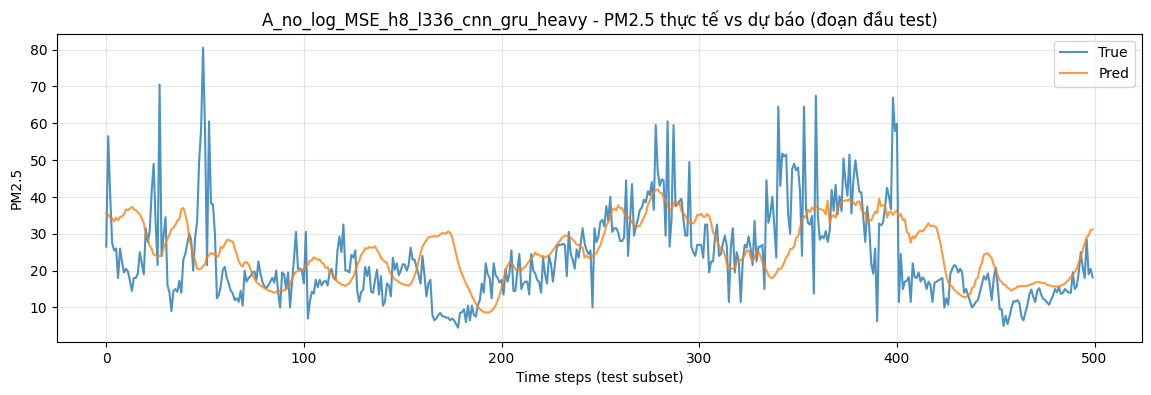


Running experiment: B_log_MAE_h8_l336_cnn_gru_heavy
Config: {'name': 'B_log_MAE_h8_l336_cnn_gru_heavy', 'transform': 'log', 'lookback': 336, 'horizon': 8, 'loss': 'mae', 'arch': 'heavy'}


/content/hoankiem-air-quality-/src/data_utils.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.7099 - mae: 0.5291 - val_loss: 0.7390 - val_mae: 0.7390 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.6178 - mae: 0.4730 - val_loss: 0.7733 - val_mae: 0.7733 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.5741 - mae: 0.4430 - val_loss: 0.7030 - val_mae: 0.7030 - learning_rate: 0.0010
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.5464 - mae: 0.4241 - val_loss: 0.7272 - val_mae: 0.7272 - learning_rate: 0.0010
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.5206 - mae: 0.4062 - val_loss: 0.7695 - val_mae: 0.7695 - learning_rate: 0.0010
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.4983 - mae: 0.3906 - val_loss: 0.6696 - val_mae: 0.6696 - learning_rate: 0.0010
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.4837 - mae: 0.3780 - val_loss: 0.6463 - val_mae: 0.6463 - learnin

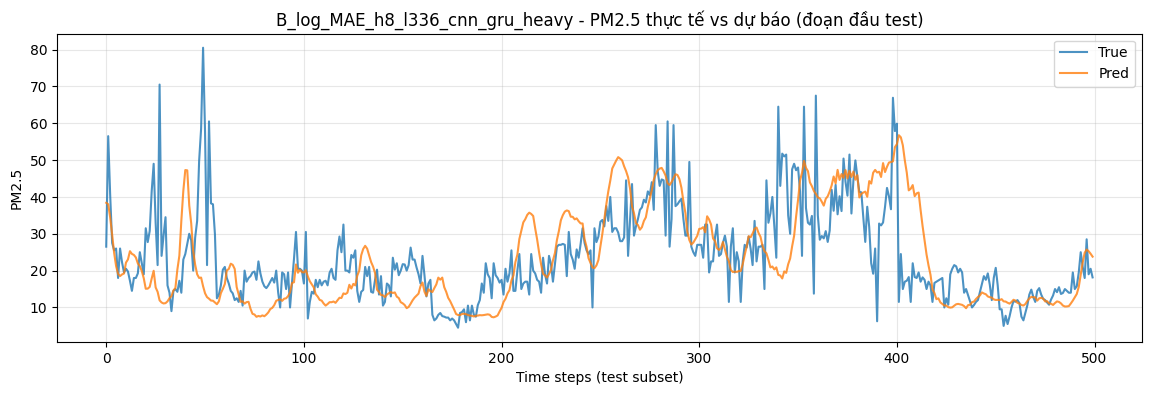


Running experiment: C_no_log_MSE_h1_l168_cnn_gru_light
Config: {'name': 'C_no_log_MSE_h1_l168_cnn_gru_light', 'transform': 'none', 'lookback': 168, 'horizon': 1, 'loss': 'mse', 'arch': 'light'}


/content/hoankiem-air-quality-/src/data_utils.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.6786 - mae: 0.3498 - val_loss: 0.4657 - val_mae: 0.4959 - learning_rate: 0.0010
Epoch 2/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.4592 - mae: 0.2857 - val_loss: 0.4154 - val_mae: 0.4717 - learning_rate: 0.0010
Epoch 3/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.4190 - mae: 0.2664 - val_loss: 0.4060 - val_mae: 0.4708 - learning_rate: 0.0010
Epoch 4/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.3706 - mae: 0.2523 - val_loss: 0.3612 - val_mae: 0.4081 - learning_rate: 0.0010
Epoch 5/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.3422 - mae: 0.2440 - val_loss: 0.4079 - val_mae: 0.4360 - learning_rate: 0.0010
Epoch 6/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.3226 - mae: 0.2382 - val_loss: 0.3582 - val_mae: 0.3937 - learning_rate: 0.0010
Epoch 7/100
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.3040 - mae: 0.2294 - val_loss: 0.4865 - val_mae: 0.4898 - learning_rate

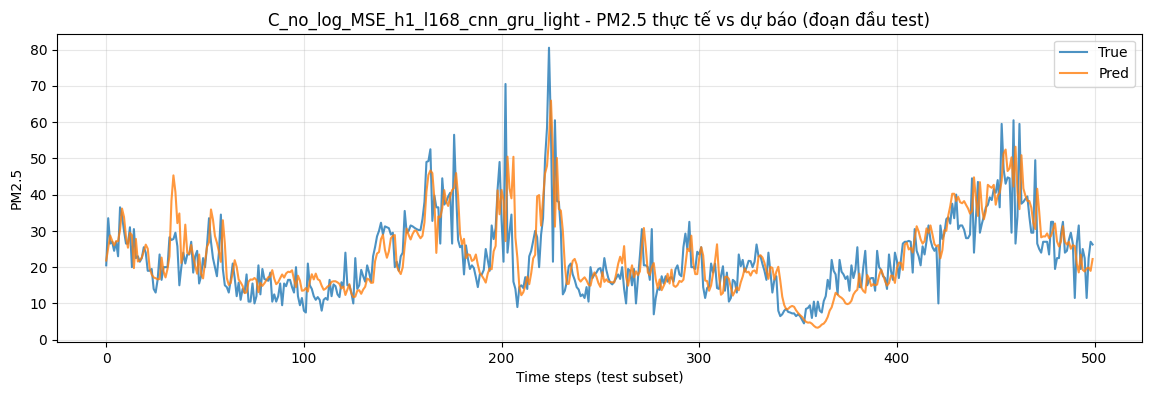


=== Tóm tắt kết quả các cấu hình ===
A_no_log_MSE_h8_l336_cnn_gru_heavy: transform=none, loss=mse, lookback=336, horizon=8 | MAE=10.0179, RMSE=14.9048
B_log_MAE_h8_l336_cnn_gru_heavy: transform=log, loss=mae, lookback=336, horizon=8 | MAE=11.1247, RMSE=16.4338
C_no_log_MSE_h1_l168_cnn_gru_light: transform=none, loss=mse, lookback=168, horizon=1 | MAE=7.1107, RMSE=10.9890


In [ ]:
# === Experiments: target transform + loss + horizon/lookback + architecture ===

experiment_configs = [
    {
        "name": "A_no_log_MSE_h8_l336_cnn_gru_heavy",
        "transform": "none",
        "lookback": 168,
        "horizon": 3,
        "loss": "mse",
        "arch": "heavy",
    },
    {
        "name": "B_log_MAE_h8_l336_cnn_gru_heavy",
        "transform": "log",
        "lookback": 336,
        "horizon": 8,
        "loss": "mae",
        "arch": "heavy",
    },
    {
        "name": "C_no_log_MSE_h1_l168_cnn_gru_light",
        "transform": "none",
        "lookback": 168,
        "horizon": 1,
        "loss": "mse",
        "arch": "light",
    },
]

results_summary = []

for cfg in experiment_configs:
    print("\n" + "=" * 80)
    print(f"Running experiment: {cfg['name']}")
    print("Config:", cfg)

    # 1) Chuẩn bị dữ liệu & sequence cho cấu hình này
    artifacts = prepare_sequences_for_experiment(
        data_path=DATA_PATH,
        target=TARGET,
        transform=cfg["transform"],
        lookback=cfg["lookback"],
        horizon=cfg["horizon"],
    )

    X_train_seq = artifacts["X_train_seq"]
    y_train_seq = artifacts["y_train_seq"]
    X_val_seq = artifacts["X_val_seq"]
    y_val_seq = artifacts["y_val_seq"]
    X_test_seq = artifacts["X_test_seq"]
    y_test_seq = artifacts["y_test_seq"]
    scaler_y = artifacts["scaler_y"]
    inverse_target_transform = artifacts["inverse_target_transform"]

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print("WARNING: empty sequences for this config, skip.")
        continue

    n_features = X_train_seq.shape[2]
    lookback = cfg["lookback"]

    # 2) Xây dựng model
    model = build_cnn_gru_model(n_features=n_features, lookback=lookback, arch=cfg["arch"])

    # 3) Chọn loss function
    loss_name = cfg["loss"].lower()
    if loss_name == "mse":
        loss_fn = tf.keras.losses.MeanSquaredError()
    elif loss_name == "mae":
        loss_fn = tf.keras.losses.MeanAbsoluteError()
    else:
        raise ValueError(f"Unsupported loss in this cell: {loss_name}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss_fn,
        metrics=["mae"],
    )

    # 4) Tăng trọng số cho các điểm y_train_seq cao (trong không gian đã transform + scale)
    thr = np.quantile(y_train_seq, 0.90)
    w_train = np.where(y_train_seq > thr, 4.0, 1.0).astype(np.float32)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq,
        sample_weight=w_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop, lr_scheduler],
        verbose=1,
    )

    # 5) Dự báo trên test và tính MAE / RMSE trong đơn vị PM2.5 gốc
    y_pred_scaled = model.predict(X_test_seq)
    y_pred_t = scaler_y.inverse_transform(y_pred_scaled)
    y_test_t_inv = scaler_y.inverse_transform(y_test_seq)

    y_pred_raw = inverse_target_transform(y_pred_t)
    y_test_raw_inv = inverse_target_transform(y_test_t_inv)

    mae_val = mean_absolute_error(y_test_raw_inv, y_pred_raw)
    rmse_val = math.sqrt(mean_squared_error(y_test_raw_inv, y_pred_raw))

    print(f"{cfg['name']} - MAE:  {mae_val:.4f}")
    print(f"{cfg['name']} - RMSE: {rmse_val:.4f}")

    # Lưu lại để so sánh sau
    results_summary.append(
        {
            "name": cfg["name"],
            "transform": cfg["transform"],
            "lookback": cfg["lookback"],
            "horizon": cfg["horizon"],
            "loss": cfg["loss"],
            "arch": cfg["arch"],
            "mae": float(mae_val),
            "rmse": float(rmse_val),
        }
    )

    # 6) Vẽ nhanh đồ thị so sánh y_true vs y_pred trên 1 đoạn test
    plt.figure(figsize=(14, 4))
    n_plot = min(500, len(y_test_raw_inv))
    plt.plot(y_test_raw_inv[:n_plot], label="True", alpha=0.8)
    plt.plot(y_pred_raw[:n_plot], label="Pred", alpha=0.8)
    plt.title(f"{cfg['name']} - PM2.5 thực tế vs dự báo (đoạn đầu test)")
    plt.xlabel("Time steps (test subset)")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


print("\n=== Tóm tắt kết quả các cấu hình ===")
for r in results_summary:
    print(
        f"{r['name']}: transform={r['transform']}, loss={r['loss']}, "
        f"lookback={r['lookback']}, horizon={r['horizon']} | "
        f"MAE={r['mae']:.4f}, RMSE={r['rmse']:.4f}"
    )


In [8]:
set_seed()
df = load_and_clean_data(DATA_PATH)
df.head()

/content/hoankiem-air-quality-/src/data_utils.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["IsHoliday"] = df["IsHoliday"].ffill().bfill().astype(int)


,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,HolidayName,IsHoliday,Accumulated Hours of Rain
Local Time,,,,,,,,,,,,,,,,
2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100.0,0.00,1020.0,95.0,15.5,0.6,2.00,Ngày thường,0,0.0
2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91.0,0.00,1021.0,94.0,15.4,0.7,2.33,Ngày thường,0,0.0
2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83.0,0.50,1022.0,93.0,15.3,1.0,2.66,Ngày thường,0,1.0
2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75.0,0.75,1022.0,93.0,15.2,1.5,3.00,Ngày thường,0,2.0
2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83.0,0.00,1021.0,87.0,15.6,1.9,3.00,Ngày thường,0,0.0


In [9]:
# 2 feature engineering
df = add_time_features(df)
df = add_target_features(df)

# 3 split time-series
train_df, val_df, test_df = split_data(df)


In [10]:

# 4 transform target
y_train, y_val, y_test, scaler_y, inverse_target_transform = transform_target(
    train_df, val_df, test_df
)

# 5 preprocess features
X_train, X_val, X_test, preprocess = preprocess_features(
    train_df, val_df, test_df
)

# 6 create sequences
X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)


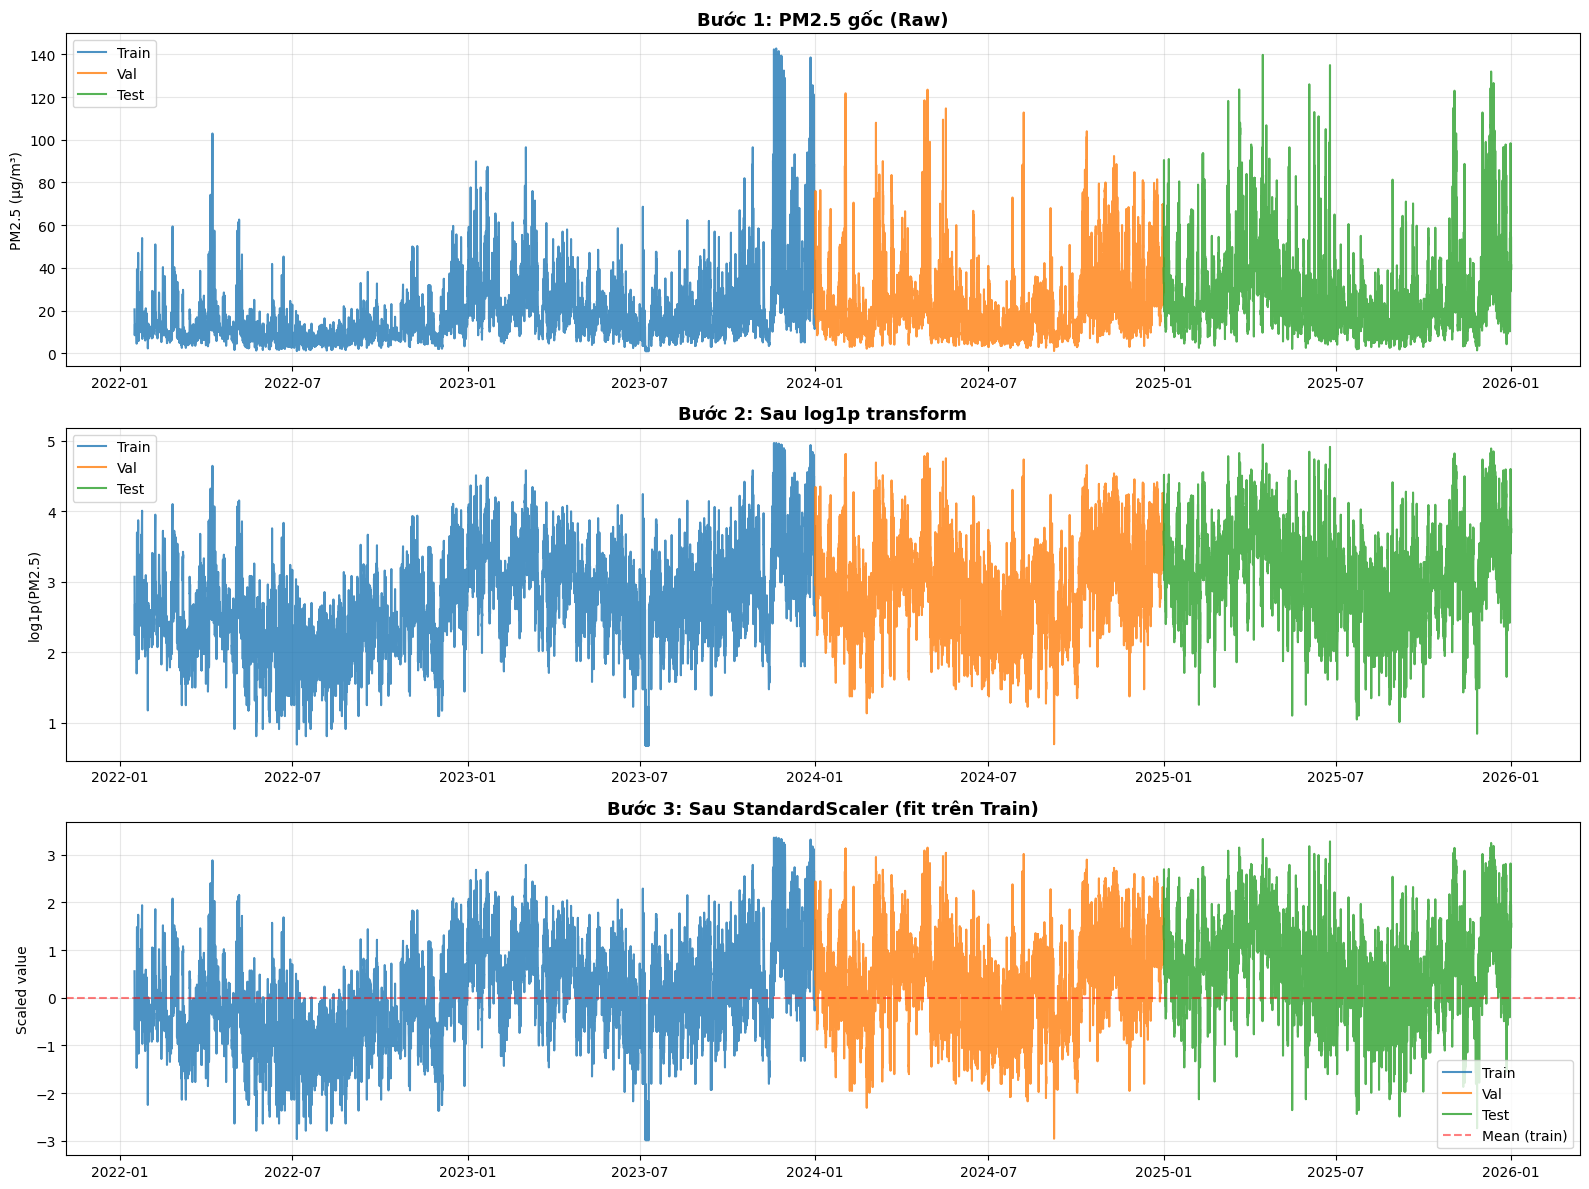

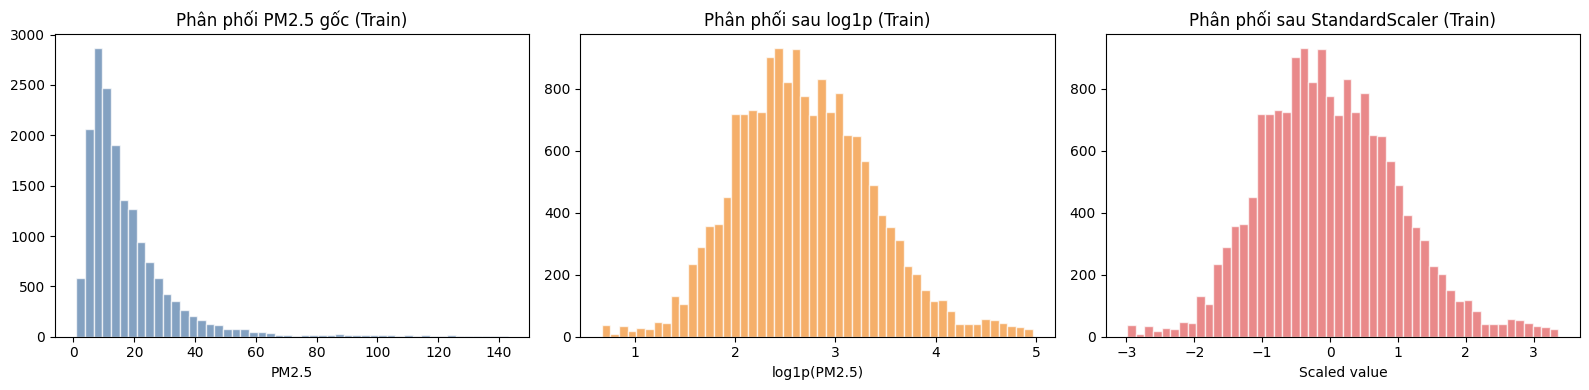

=== Thống kê qua từng bước ===
Raw      | Mean:   17.915 | Std:  16.373 | Min:    0.960 | Max: 142.800 | Skew:  3.172
Log1p    | Mean:    2.693 | Std:   0.676 | Min:    0.673 | Max:   4.968 | Skew:  0.319
Scaled   | Mean:    0.000 | Std:   1.000 | Min:   -2.987 | Max:   3.365 | Skew:  0.319


In [11]:
# Raw target
y_train_raw = train_df[[TARGET]].values
y_val_raw   = val_df[[TARGET]].values
y_test_raw  = test_df[[TARGET]].values

def forward(y):
    y = np.asarray(y, dtype=np.float64)
    return np.log1p(np.clip(y, 0, None))

y_train_t = forward(y_train_raw)
y_val_t   = forward(y_val_raw)
y_test_t  = forward(y_test_raw)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train_t)
y_val_s   = scaler_y.transform(y_val_t)
y_test_s  = scaler_y.transform(y_test_t)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

# 1) Raw
axes[0].plot(train_df.index, y_train_raw.ravel(), label='Train', alpha=0.8)
axes[0].plot(val_df.index,   y_val_raw.ravel(),   label='Val',   alpha=0.8)
axes[0].plot(test_df.index,  y_test_raw.ravel(),  label='Test',  alpha=0.8)
axes[0].set_title('Bước 1: PM2.5 gốc (Raw)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2) Log1p
axes[1].plot(train_df.index, y_train_t.ravel(), label='Train', alpha=0.8)
axes[1].plot(val_df.index,   y_val_t.ravel(),   label='Val',   alpha=0.8)
axes[1].plot(test_df.index,  y_test_t.ravel(),  label='Test',  alpha=0.8)
axes[1].set_title('Bước 2: Sau log1p transform', fontsize=13, fontweight='bold')
axes[1].set_ylabel('log1p(PM2.5)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 3) Scaled
axes[2].plot(train_df.index, y_train_s.ravel(), label='Train', alpha=0.8)
axes[2].plot(val_df.index,   y_val_s.ravel(),   label='Val',   alpha=0.8)
axes[2].plot(test_df.index,  y_test_s.ravel(),  label='Test',  alpha=0.8)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Mean (train)')
axes[2].set_title('Bước 3: Sau StandardScaler (fit trên Train)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Scaled value')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.7, color='#4e79a7', edgecolor='white')
axes[0].set_title('Phân phối PM2.5 gốc (Train)'); axes[0].set_xlabel('PM2.5')

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.7, color='#f28e2b', edgecolor='white')
axes[1].set_title('Phân phối sau log1p (Train)'); axes[1].set_xlabel('log1p(PM2.5)')

axes[2].hist(y_train_s.ravel(), bins=50, alpha=0.7, color='#e15759', edgecolor='white')
axes[2].set_title('Phân phối sau StandardScaler (Train)'); axes[2].set_xlabel('Scaled value')

plt.tight_layout()
plt.show()

print("=== Thống kê qua từng bước ===")
for name, data in [("Raw", y_train_raw), ("Log1p", y_train_t), ("Scaled", y_train_s)]:
    d = data.ravel()
    print(f"{name:8s} | Mean: {d.mean():8.3f} | Std: {d.std():7.3f} | "
          f"Min: {d.min():8.3f} | Max: {d.max():7.3f} | Skew: {pd.Series(d).skew():6.3f}")


In [ ]:
print("Kích thước tập train:", train_df.shape)
print("Kích thước tập validation:", val_df.shape)
print("Kích thước tập test:", test_df.shape)

Kích thước tập train: (17153, 35)
Kích thước tập validation: (8784, 35)
Kích thước tập test: (8760, 35)


In [13]:
n_features = X_train_seq.shape[2]  
model_cnn_gru = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', 
           padding='same', input_shape=(LOOKBACK, n_features)),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    GRU(256, return_sequences=True),
    Dropout(0.2),
    GRU(128,  return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Output layer cho dự đoán PM2.5
])

model_cnn_gru.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae']
)
model_cnn_gru.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 336, 64)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 336, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 168, 256)       │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 168, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 168, 128)       │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,553 (1.74 MB)

 Trainable params: 455,553 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
thr = np.quantile(y_train_seq, 0.90)
w_train = np.where(y_train_seq > thr, 4.0, 1.0).astype(np.float32)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


early_stop_cnn_gru = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)
history_cnn_gru = model_cnn_gru.fit(
    X_train_seq, y_train_seq,
    sample_weight=w_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_cnn_gru, lr_scheduler],
    verbose=1
)

Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.2764 - mae: 0.5150 - val_loss: 0.3256 - val_mae: 0.6734 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.2132 - mae: 0.4501 - val_loss: 0.3001 - val_mae: 0.6435 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.1870 - mae: 0.4210 - val_loss: 0.3574 - val_mae: 0.7176 - learning_rate: 0.0010
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.1681 - mae: 0.4000 - val_loss: 0.3203 - val_mae: 0.6689 - learning_rate: 0.0010
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 0.1536 - mae: 0.3800 - val_loss: 0.2933 - val_mae: 0.6354 - learning_rate: 0.0010
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.1432 - mae: 0.3671 - val_loss: 0.3467 - val_mae: 0.7025 - learning_rate: 0.0010
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.1356 - mae: 0.3549 - val_loss: 0.3436 - val_mae: 0.6955 - learnin

In [15]:
n_features = X_train_seq.shape[2]

model_gru = Sequential([
    tf.keras.Input(shape=(LOOKBACK, n_features)),
    GRU(256, return_sequences=True),
    Dropout(0.2),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# model_gru.compile(optimizer='adam', loss='mae', metrics=['mae'])
model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.Huber(delta=1.0),   
    metrics=['mae']
)
model_gru.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 336, 256)       │       231,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 336, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ (None, 336, 128)       │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 336, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,753 (1.60 MB)

 Trainable params: 418,753 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:

y_pred_gru_scaled = model_cnn_gru.predict(X_test_seq)

y_pred_t = scaler_y.inverse_transform(y_pred_gru_scaled)
y_test_t_inv = scaler_y.inverse_transform(y_test_seq)

y_pred_raw = inverse_target_transform(y_pred_t)
y_test_raw_inv = inverse_target_transform(y_test_t_inv)


mae_cnn_gru  = mean_absolute_error(y_test_raw_inv, y_pred_raw)
rmse_cnn_gru = math.sqrt(mean_squared_error(y_test_raw_inv, y_pred_raw))

print(f"CNN-GRU - MAE:  {mae_cnn_gru:.4f}")
print(f"CNN-GRU - RMSE: {rmse_cnn_gru:.4f}")

264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
CNN-GRU - MAE:  10.9159
CNN-GRU - RMSE: 15.9411


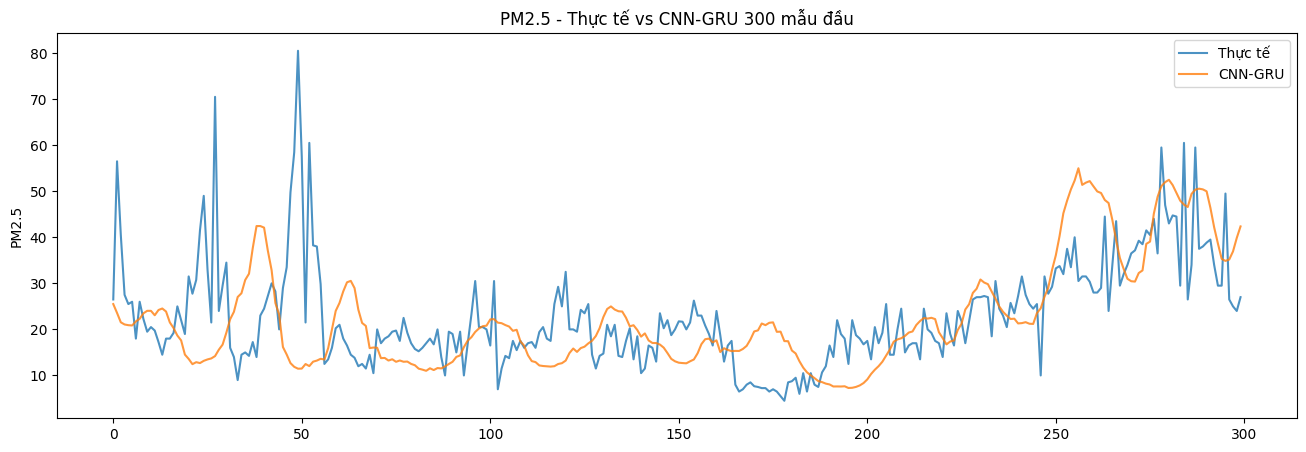

In [17]:
N = 300

plt.figure(figsize=(16, 5))
plt.plot(y_test_raw_inv[:N], label='Thực tế', alpha=0.8)
plt.plot(y_pred_raw[:N],     label='CNN-GRU', alpha=0.8)


plt.legend()
plt.title(f'PM2.5 - Thực tế vs CNN-GRU {N} mẫu đầu')
plt.ylabel('PM2.5')
plt.show()